In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import gdown
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture

Загружаем и смотрим данные

In [28]:
sns.set(style="whitegrid", context="notebook")
random_state = 42
np.random.seed(random_state)


file_id = "1Z44FrzWtVlulLkEMjilj61zRY5ieTLOe"
url = f"https://drive.google.com/uc?id={file_id}"

output_file = "Run200_Wave_0_1.txt"


gdown.download(url, output_file, quiet=False)

raw_df = pd.read_csv(
    output_file,
    sep=' ',
    header=None,
    skipinitialspace=True
    )

print("Загруженный файл:", output_file)
print("Shape raw_df:", raw_df.shape)
display(raw_df.head())
raw_df.info()
print("Список колонок raw_df:")
print(raw_df.columns.tolist())


dataset = raw_df.drop([0, 1, 2, 3, 504], axis=1)

dataset.columns = list(range(500))

print("Shape dataset:", dataset.shape)
display(dataset.head())

display(dataset.describe().T.head(10))


Downloading...
From: https://drive.google.com/uc?id=1Z44FrzWtVlulLkEMjilj61zRY5ieTLOe
To: /content/Run200_Wave_0_1.txt
100%|██████████| 71.3M/71.3M [00:00<00:00, 87.9MB/s]


Загруженный файл: Run200_Wave_0_1.txt
Shape raw_df: (23479, 505)


,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14821,14820,14820,14818,14821,14823,14820,14820,14821,NaN
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14826,14822,14821,14820,14828,14820,14822,14823,14822,NaN
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14823,14828,14824,14820,14824,14824,14822,14825,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 505 entries, 0 to 504
dtypes: float64(1), int64(504)
memory usage: 90.5 MB
Список колонок raw_df:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 1

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


,count,mean,std,min,25%,50%,75%,max
0,23479.0,14822.972316,2.805884,14812.0,14821.0,14823.0,14824.0,14834.0
1,23479.0,14822.958474,2.833516,14812.0,14821.0,14823.0,14824.0,14835.0
2,23479.0,14822.970016,2.840755,14812.0,14821.0,14823.0,14825.0,14834.0
3,23479.0,14822.989991,2.852066,14811.0,14821.0,14823.0,14825.0,14835.0
4,23479.0,14823.003961,2.833412,14812.0,14821.0,14823.0,14825.0,14834.0
5,23479.0,14822.978619,2.836271,14812.0,14821.0,14823.0,14824.0,14835.0
6,23479.0,14822.968610,2.831241,14812.0,14821.0,14823.0,14824.0,14835.0
7,23479.0,14822.954470,2.827526,14811.0,14821.0,14823.0,14824.0,14833.0
8,23479.0,14822.963670,2.846291,14812.0,14821.0,14823.0,14824.0,14834.0
9,23479.0,14822.968908,2.814655,14809.0,14821.0,14823.0,14824.0,14834.0


In [31]:
dataset.shape
print("Shape dataset:", dataset.shape)

Shape dataset: (23479, 500)


В датасете 23479 сигналов, каждый описывается 500 отсчётами

mean около 14823 (во всех столбцах значения очень близки),
std примерно 2.8 (очень маленький разброс),
min около 14809–14812,
25%, 50%, 75% почти совпадают (14821–14825),
max около 14833–14835.
Это говорит о том, что:
первые десятки отсчётов содержат baseline, а не сам импульс. Соответственно распределение узкое и дисперсия минимальна.
Это  значит, что базовый уровень стабильный.

Посмотрим пропуски по строкам и столбцам

In [3]:
missing_dataset = dataset.isna().sum()

print("Число пропусков по столбцам (dataset):")
print(missing_dataset[missing_dataset > 0])

print("\nВсего пропусков в dataset:", missing_dataset.sum())

row_missing = dataset.isna().sum(axis=1)

print("Пропуски по строкам:")
print(row_missing.value_counts().sort_index().head(10))

rows_with_missing = dataset[row_missing > 0]
print("строки с одним NaN:", len(rows_with_missing))

Число пропусков по столбцам (dataset):
Series([], dtype: int64)

Всего пропусков в dataset: 0
Пропуски по строкам:
0    23479
Name: count, dtype: int64
строки с одним NaN: 0


Проверяем дубликаты

In [6]:
print("До", dataset.shape)

dataset = dataset.drop_duplicates()

print("После удаления дубликатов:", dataset.shape)

До (23479, 500)
После удаления дубликатов: (23479, 500)


Дубликатов нет.
Посмотрим константные столбцы. Их можно удалить, как неинформативные

In [8]:
const_cols = [col for col in dataset.columns if dataset[col].nunique() <= 1]
print("Константы:", len(const_cols))
print(const_cols[:20])

if const_cols:
    dataset = dataset.drop(columns=const_cols)
    print("После удаления констант:", dataset.shape)

Константы: 0
[]


Константных столбцов нет, удалять нечего.

Text(0, 0.5, 'bit ADC')

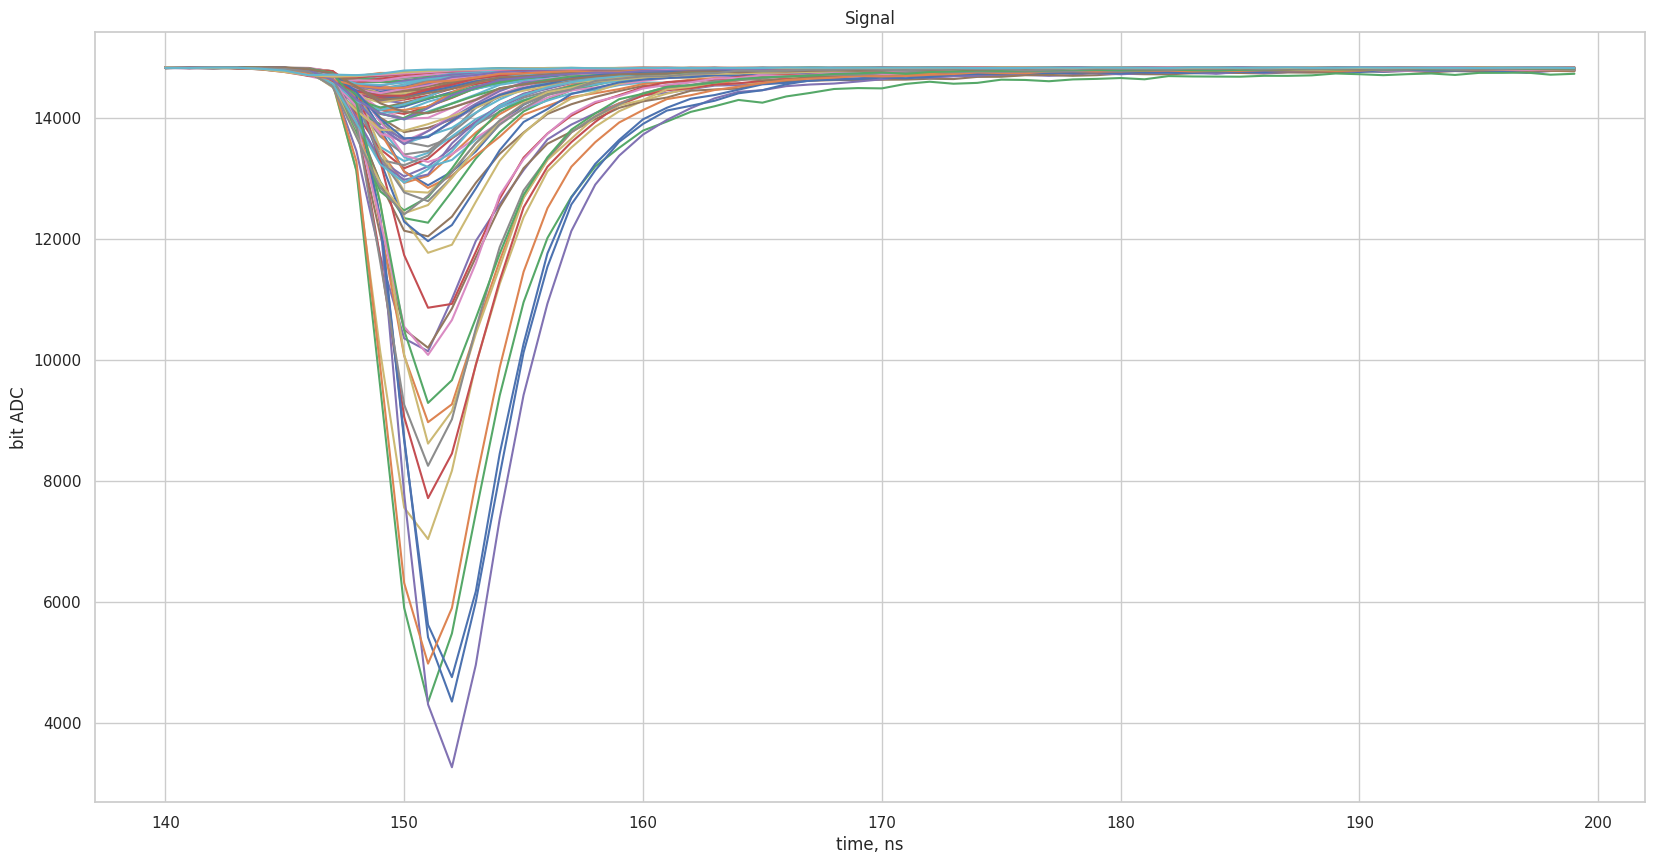

In [ ]:
N=range(0,100)
ax = dataset.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Сделано транспонирование, взяты первые 100 событий и в результате видим вспышки по оси X c амплитудой по оси Y

Text(0, 0.5, 'bit ADC')

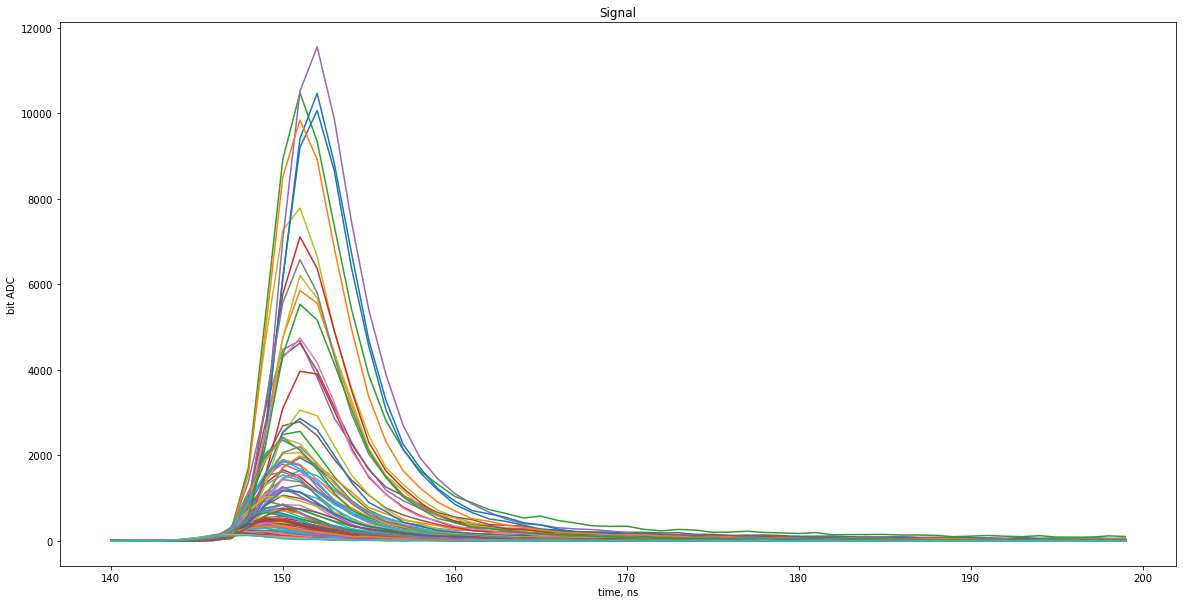

In [ ]:
ax = (2**14-dataset.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


На второй диаграмме инвертированная картинка от первой, т.е. пик развернут вверх.
Предлагаю посмотреть describe  вокруг значения пика (145-156)

In [ ]:
pulse_cols = list(range(145, 156))
desc_pulse = dataset[pulse_cols].describe().T
display(desc_pulse)

,count,mean,std,min,25%,50%,75%,max
145,23479.0,14805.719877,21.561878,14673.0,14804.0,14813.0,14818.0,14832.0
146,23479.0,14770.765706,36.435748,14654.0,14746.0,14783.0,14800.0,14824.0
147,23479.0,14659.352570,65.141686,14470.0,14617.0,14667.0,14706.0,14790.0
148,23479.0,14328.765535,323.325048,12588.0,14197.5,14412.0,14552.0,14758.0
149,23479.0,13753.165808,1032.985540,7425.0,13303.0,14104.0,14522.0,14782.0
150,23479.0,13231.913327,1904.907097,1572.0,12610.5,14021.0,14561.0,14802.0
151,23479.0,13071.555560,2389.392164,0.0,12567.0,14112.0,14617.0,14812.0
152,23479.0,13270.455130,2285.339760,0.0,12928.0,14268.0,14669.0,14813.0
153,23479.0,13611.726053,1852.426511,0.0,13382.0,14414.0,14708.0,14817.0
154,23479.0,13939.853571,1362.100857,25.0,13780.0,14524.0,14736.0,14822.0


Область импульса сильно отличается от baseline, который смотрели выше.
Это значит, что в диапазоне примерно 147–154 отсчётов находится максимум импульса и основная вариативность сигналов.Здесь сигналы могут сильно отличаться по амплитуде — от 0  до очень крупных вспышек.
Виден резкий разброс  по сравнению с baseline: стандартное отклонение возрастает с  21 до 2389.
 Средние значения при этом снижаются относительно baseline, что связано с тем, что часть событий имеет малые амплитуды, а часть — крупные импульсы.
 Таким образом, именно в окне 145–156 сосредоточена основная информация о различиях между сигналами.
С учетом этих результатов:
в раннем окне (0–100 отсчётов) сигнал почти константный и отражает стабильный baseline;
основная вариативность и максимум импульса приходятся на область 145–156 отсчётов;
значимая часть информации о различиях сигналов содержится в форме и «доле хвоста» импульса.

Возьмем интегральные признаки (total_integral, tail_integral, tail_to_total)  в качестве ключевых, поскольку площадь под импульсом пропорциональна суммарному количеству зарегистрированных фотонов и хорошо коррелирует с энергией события. В отличие от максимальной амплитуды, интеграл агрегирует информацию по всему импульсу и менее чувствителен к локальному шуму.

In [9]:
baseline_window = range(0, 100)
baseline = dataset[baseline_window].mean(axis=1)
signals_bs = dataset.sub(baseline, axis=0)


main_window = range(130, 200)
tail_window = range(160, 200)

features = pd.DataFrame(index=signals_bs.index)


features["total_integral"] = signals_bs[main_window].sum(axis=1)
features["tail_integral"] = signals_bs[tail_window].sum(axis=1)

eps = 1e-6
features["tail_to_total"] = features["tail_integral"] / (features["total_integral"] + eps)


peak_amplitude = signals_bs.max(axis=1)
t_peak = signals_bs.values.argmax(axis=1)

features["peak_amplitude"] = peak_amplitude
features["t_peak"] = t_peak

def rise_time_10_90(row):
    sig = row.values
    pk = sig.max()
    if pk <= 0:
        return np.nan
    thr_10 = 0.1 * pk
    thr_90 = 0.9 * pk
    try:
        t10 = np.where(sig >= thr_10)[0][0]
        t90 = np.where(sig >= thr_90)[0][0]
        return t90 - t10
    except IndexError:
        return np.nan

features["rise_time_10_90"] = signals_bs.apply(rise_time_10_90, axis=1)

print("Features shape:", features.shape)
display(features.head())

features_desc = features.describe().T
display(features_desc)

Features shape: (23479, 6)


,total_integral,tail_integral,tail_to_total,peak_amplitude,t_peak,rise_time_10_90
0,-4002.1,-741.2,0.185203,8.87,25,24
1,-11731.9,-988.8,0.084283,5.53,26,23
2,-16304.4,-1409.8,0.086467,8.08,338,335
3,-4151.2,-697.4,0.168000,8.24,320,320
4,-11298.1,-942.2,0.083395,6.57,36,36


,count,mean,std,min,25%,50%,75%,max
total_integral,23479.0,-12302.478956,15318.033397,-109409.100000,-15975.35000,-5729.800000,-2227.950000,-582.600000
tail_integral,23479.0,-1584.864722,1908.560589,-14372.000000,-2211.60000,-800.000000,-280.300000,53.000000
tail_to_total,23479.0,0.134651,0.057008,-0.070292,0.08356,0.136317,0.188096,0.294793
peak_amplitude,23479.0,7.746253,1.234035,3.970000,6.88000,7.670000,8.530000,15.520000
t_peak,23479.0,198.072874,165.293308,0.000000,50.00000,123.000000,360.000000,499.000000
rise_time_10_90,23479.0,196.009626,165.020561,0.000000,48.00000,121.000000,358.000000,499.000000


Признаки total_integral и tail_integral демонстрируют широкий диапазон значений и большое стандартное отклонение, что отражает сильный разброс по общей площади импульса и хвостовой части сигнала. Абсолютные значения интегралов достигают порядка 10 000,что соответствует существенным различиям в зарегистрированной энергии событий. Знак интегралов отрицателен, поскольку после вычитания baseline импульс представлен в виде отклонения вниз относительно нулевого уровня, однако для целей кластеризации важен именно модуль и относительные различия между событиями.



Отношение tail_to_total для основной массы событий лежит в диапазоне 0.08–0.19, что означает, что вклад хвостовой части импульса составляет порядка 10–20% от полной площади. При этом присутствуют события с существенно большей долей хвоста (до 0.297), а также небольшое количество аномальных значений (tail_to_total < 0), возникающих в случаях, когда интеграл по основному окну мал или имеет близкое к нулю значение. Такая вариативность tail_to_total указывает на то, что форма хвоста существенно различается между сигналами, и делает этот признак перспективным для разделения кластеров, связанных с разными типами частиц.

Признак peak_amplitude имеет сравнительно небольшой разброс по сравнению с интегралами: большинство значений сосредоточено в диапазоне 7–9, при этом встречаются как более слабые, так и более мощные импульсы. Это говорит о том, что по одной только максимальной амплитуде сигналы различаются умеренно, а основное разнообразие связано именно с формой и длительностью импульса, а не только с высотой пика.
Распределения t_peak и rise_time_10_90 очень широкие: значения варьируются практически по всему диапазону , а медианы лежат в области 120–130 отсчётов. В результате t_peak и rise_time_10_90 оказываются менее стабильными и, вероятно, будут играть вспомогательную роль по сравнению с интегральными признаками и tail_to_total


Теперь хорошо бы нормировать признаки (StandardScaler) и посмотреть на корреляционную матрицу:
насколько total_integral и tail_integral коррелируют,
как связаны tail_to_total и peak_amplitude

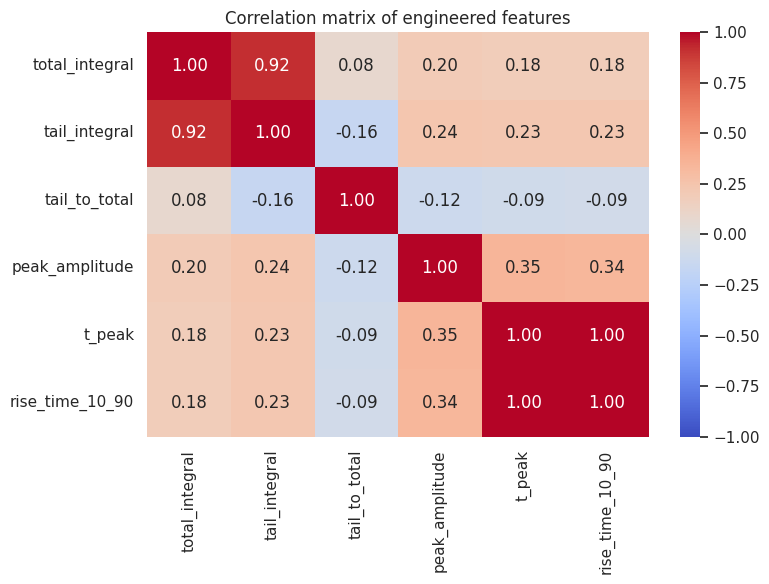

In [ ]:
corr = features.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

Из матрицы видно, что что total_integral и tail_integral сильно связаны между собой (коэффициент корреляции 0.92), т.к. хвостовая часть импульса является компонентой полной площади под сигналом. В то же время отношение tail_to_total слабо коррелирует с total_integral и даже имеет слабую отрицательную корреляцию с tail_integral, что указывает на относительную независимость этого признака о и подтверждает его пригодность для описания формы хвоста.

Признак peak_amplitude демонстрирует умеренную связь с интегральными характеристиками и более сильную корреляцию с временными параметрами t_peak и rise_time_10_90. При этом t_peak и rise_time_10_90 практически полностью коррелированы.
В целом полученный набор признаков содержит как сильно коррелированные (total_integral и tail_integral), так и относительно независимые параметры (tail_to_total, временные характеристики), что создаёт основу для выделения устойчивых кластеров в пространстве признаков.

Берем Kmeans и GMM, т.к. у нас задано кол-во кластеров в задании ( 3 шт).

Сначала делаем нормировку и РСА.

In [10]:
features_filled = features.fillna(features.mean())


scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_filled)


pca = PCA(n_components=2, random_state=random_state)
X_pca = pca.fit_transform(X_scaled)

print("Shape X_scaled:", X_scaled.shape)
print("Explained variance ratio (2 PCs):", pca.explained_variance_ratio_)
print("Total explained variance (2 PCs):", pca.explained_variance_ratio_.sum())

Shape X_scaled: (23479, 6)
Explained variance ratio (2 PCs): [0.43211823 0.26057887]
Total explained variance (2 PCs): 0.6926971050186863


Для анализа структуры данных кластеров была выполнена проекция признакового пространства на первые две главные компоненты. Две компоненты объясняют около 69% общей дисперсии (43% и 26% соответственно), что обеспечивает достаточно информативное отображение структуры данных в двумерном пространстве, при этом оставшаяся часть дисперсии учитывается в полном 6-мерном пространстве при обучении моделей кластеризации.
Т.е. 6 исходных признаков, после стандартизации две первые компоненты показывают около 69% вариации:

PC1 около 43%;
PC2 около 26%

Посмотрим  РСА визуально

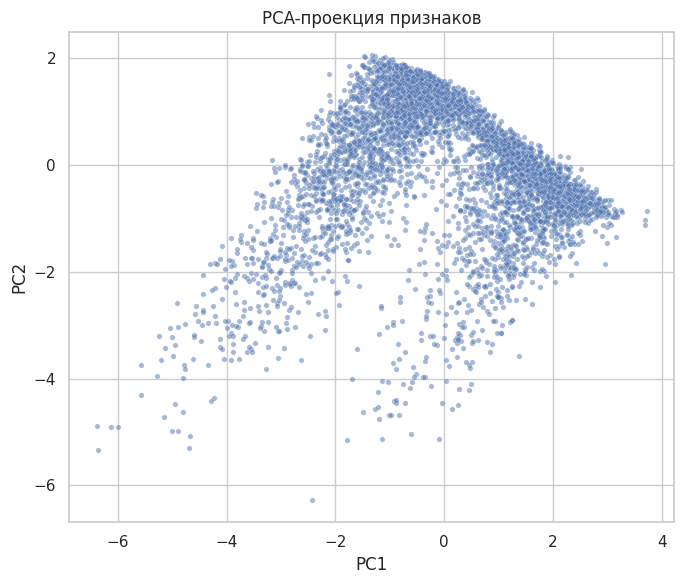

In [15]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

plt.figure(figsize=(7, 6))
sns.scatterplot(data=pca_df.sample(5000, random_state=random_state),
                x="PC1", y="PC2", alpha=0.5, s=15)
plt.title("PCA-проекция признаков")
plt.tight_layout()
plt.show()

В PCA-проекции признаков основная часть событий формирует плотную область, тогда как часть точек образует хвост, который вытянут и есть разреженные группы в нижней части диаграммы(похоже на выбросы). Это указывает на наличие по крайней мере двух основных популяций и 1 дополнительной группы аномальных сигналов, а это как раз согласуется с постановкой задачи (два типа частиц + 1 аномальный кластер)

Берем KMeans (k=3), т.к. к=3 задано в условии и видно по РСА

In [19]:
kmeans = KMeans(
    n_clusters=3,
    random_state=random_state,
    n_init=20
)

labels_km = kmeans.fit_predict(X_scaled)

sil_km =silhouette_score(X_scaled, labels_km)
ch_km =calinski_harabasz_score(X_scaled, labels_km)
db_km =davies_bouldin_score(X_scaled, labels_km)

print("KMeans (k=3):")
print("Silhouette:", sil_km)


kmeans = KMeans(
    n_clusters=3,
    random_state=random_state,
    n_init=20
)

labels_km = kmeans.fit_predict(X_scaled)

sil_km =silhouette_score(X_scaled, labels_km)
ch_km =calinski_harabasz_score(X_scaled, labels_km)
db_km=davies_bouldin_score(X_scaled, labels_km)

display("KMeans (k=3):")
display("Silhouette:", sil_km)

KMeans (k=3):
Silhouette: 0.34015663845106275


'KMeans (k=3):'

'Silhouette:'

np.float64(0.34015663845106275)

В качестве базового алгоритма кластеризации была использована модель KMeans с числом кластеров k=3, обученная на стандартизованном пространстве признаков. Полученный коэффициент силуэта составил 0.34, что говорит о хорошей разделимости кластеров в выбранном признаковом пространстве

теперь GMM

In [20]:
cov_types = ["full", "diag", "tied", "spherical"]
results_gmm = []

for cov in cov_types:
    gmm = GaussianMixture(
        n_components=3,
        covariance_type=cov,
        random_state=random_state,
        n_init=5
    )
    gmm.fit(X_scaled)
    labels_gmm = gmm.predict(X_scaled)

    sil = silhouette_score(X_scaled, labels_gmm)
    ch = calinski_harabasz_score(X_scaled, labels_gmm)
    db = davies_bouldin_score(X_scaled, labels_gmm)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)

    results_gmm.append({
        "covariance_type": cov,
        "silhouette": sil,
         "bic": bic,
        "aic": aic,
        "labels": labels_gmm
    })

results_gmm_df = pd.DataFrame([
    {
        "covariance_type": r["covariance_type"],
        "silhouette": r["silhouette"],
        "bic": r["bic"],
        "aic": r["aic"],
    }
    for r in results_gmm
])

display(results_gmm_df)

,covariance_type,silhouette,bic,aic
0,full,0.206375,38058.111502,37388.810982
1,diag,0.275992,285851.458166,285545.031422
2,tied,0.292075,189235.955458,188905.337129
3,spherical,0.340833,341986.591297,341801.122478


В качестве базового алгоритма была обучена модель KMeans с
k=3, давшая коэффициент силуэта =0.34. Для сравнения были протестированы модели Gaussian Mixture с разными типами ковариационных матриц (full, diag, tied, spherical). Наиболее высокое значение силуэта =0.341, показал вариант GMM с сферической ковариацией, сопоставимый с результатом KMeans, тогда как более гибкие варианты (full, tied) давали меньший силуэт при более сложной модели (что также отражается в значениях BIC/AIC). Таким образом, по внутренним метрикам KMeans и GMM с spherical демонстрируют сравнимое качество разбиения на 3 кластера, при этом KMeans остаётся более простой и интерпретируемой моделью.

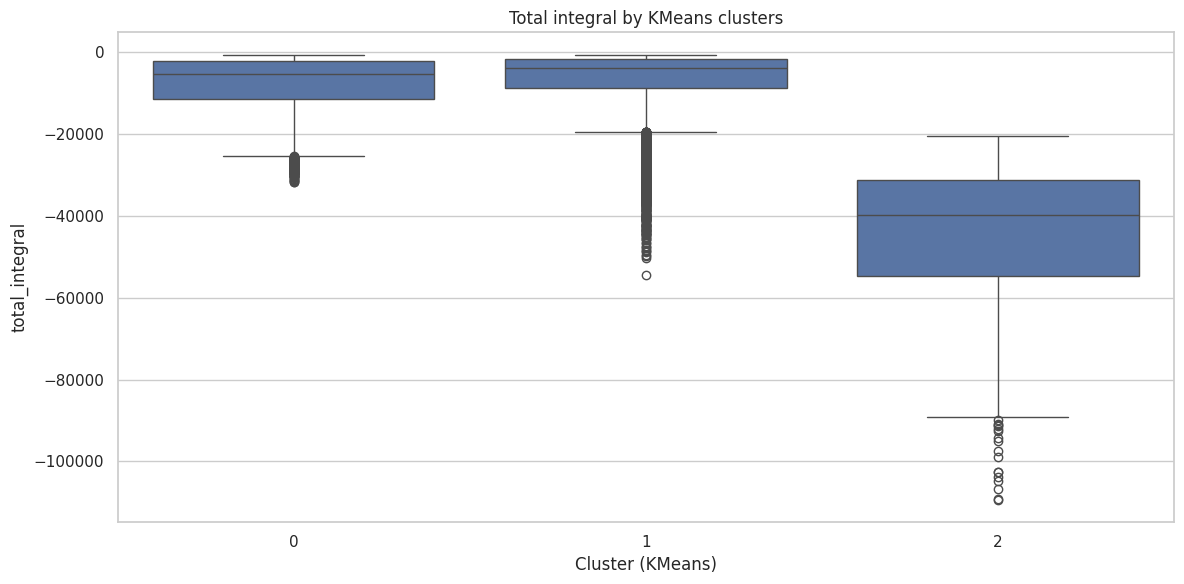

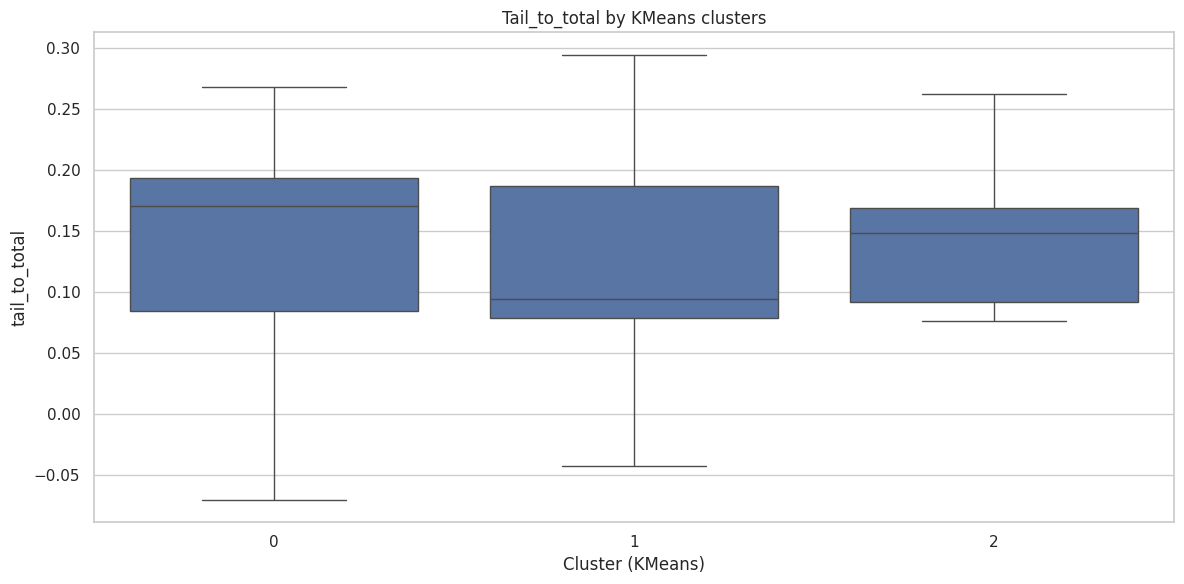

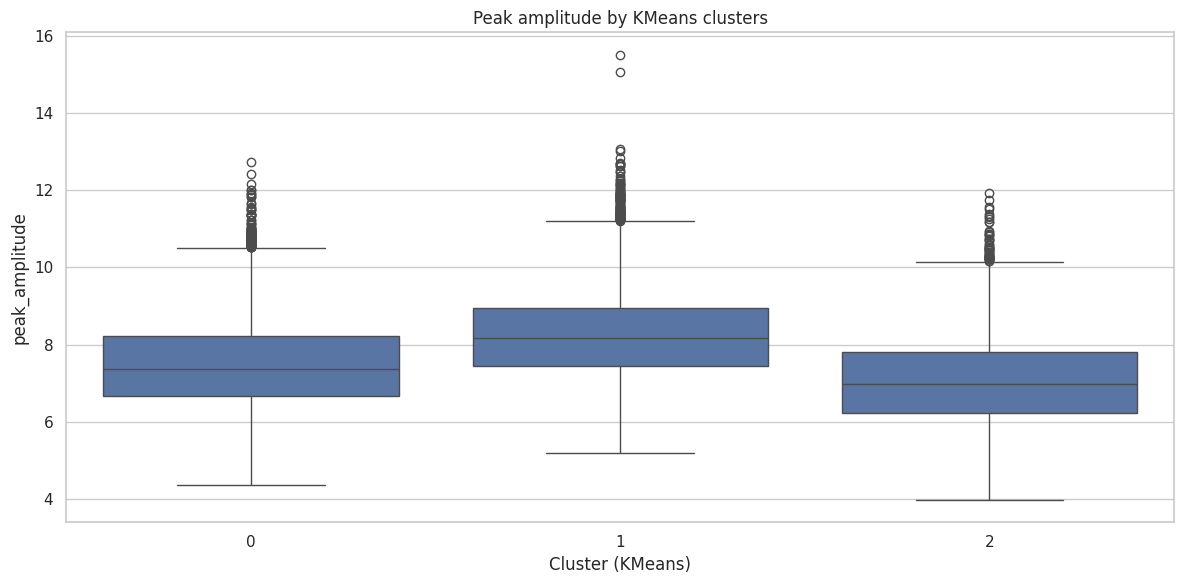

In [ ]:
features_km = features.copy()
features_km["cluster_km"] = labels_km

features_km["cluster_km"].value_counts()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=features_km,
    x="cluster_km",
    y="total_integral"
)
plt.title("Total integral by KMeans clusters")
plt.xlabel("Cluster (KMeans)")
plt.ylabel("total_integral")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=features_km,
    x="cluster_km",
    y="tail_to_total"
)
plt.title("Tail_to_total by KMeans clusters")
plt.xlabel("Cluster (KMeans)")
plt.ylabel("tail_to_total")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=features_km,
    x="cluster_km",
    y="peak_amplitude"
)
plt.title("Peak amplitude by KMeans clusters")
plt.xlabel("Cluster (KMeans)")
plt.ylabel("peak_amplitude")
plt.tight_layout()
plt.show()

Из графика анализа кластеров  видно, что

Кластер 0:медиана tail_to_total ≈ 0.17–0.18;
разброс большй, есть даже немного отрицательных/аномальных значений.

Кластер 1:
медиана ближе к 0.09, хвосты тянутся вверх до 0.29, вниз чуть ниже нуля.

Кластер 2: медиана около 0.15–0.16, разброс меньше, чем у кластера 0, диапазон примерно 0.08–0.26.

Это хорошо согласуется с тем, что написано в задании: два кластера описывают разные типы частиц (гамма/нейтрон) с отличающейся формой импульса, а третий может интерпретироваться как смешанная/аномальная группа, включающая события с нестандартной формой или низким сигналом

Посмотрим еще boxplot  для total_integral и peak_amplitude

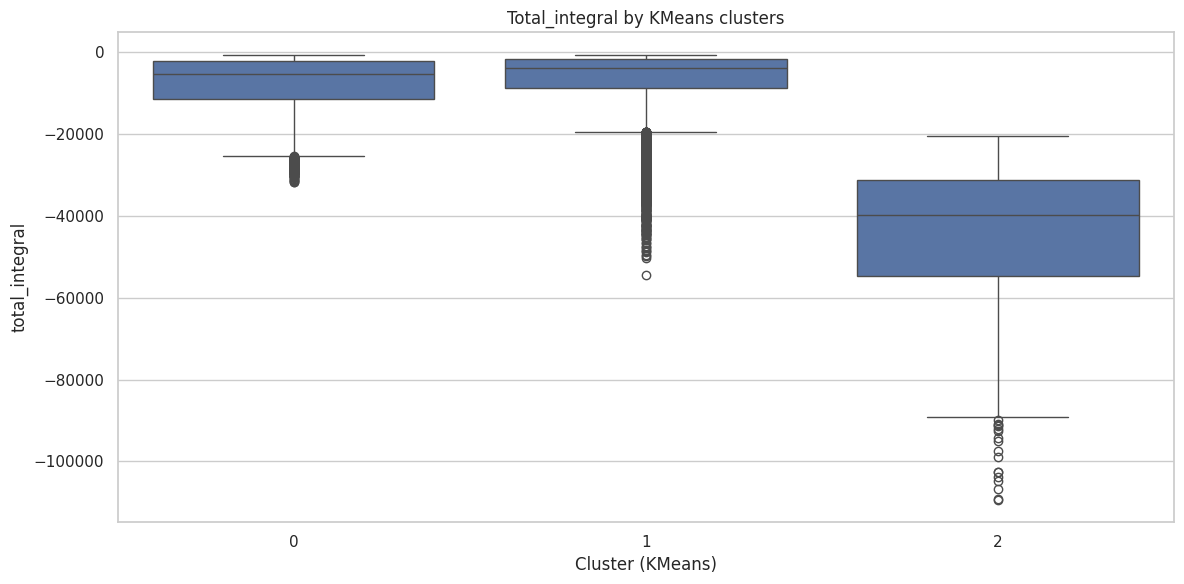

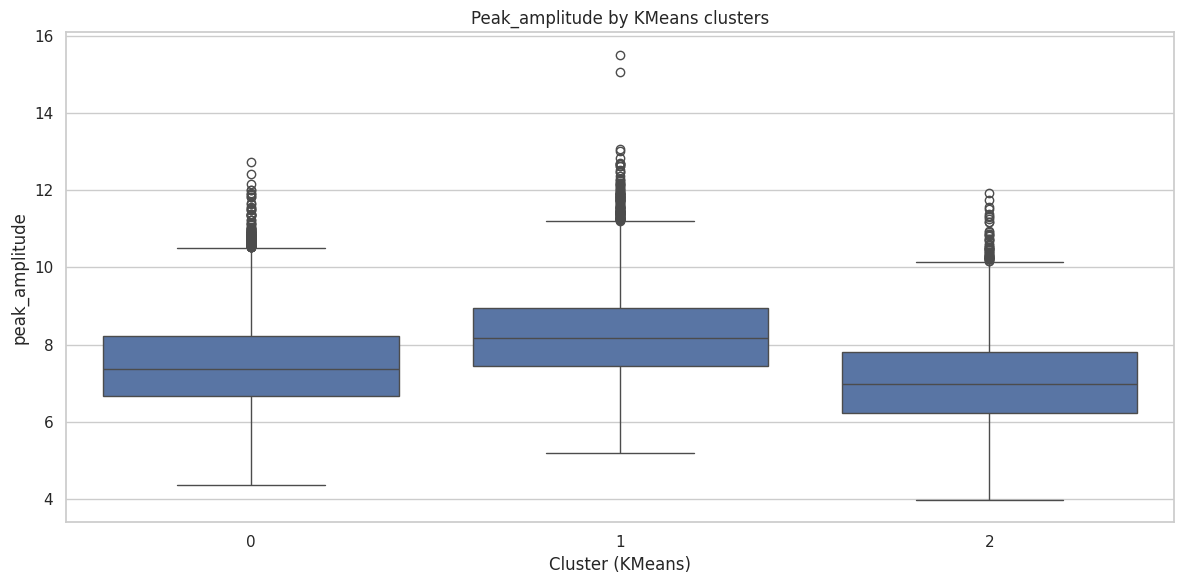

In [22]:
features_km = features.copy()
features_km["cluster_km"] = labels_km


plt.figure(figsize=(12, 6))
sns.boxplot(
    data=features_km,
    x="cluster_km",
    y="total_integral"
)
plt.title("Total_integral by KMeans clusters")
plt.xlabel("Cluster (KMeans)")
plt.ylabel("total_integral")
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
sns.boxplot(
    data=features_km,
    x="cluster_km",
    y="peak_amplitude"
)
plt.title("Peak_amplitude by KMeans clusters")
plt.xlabel("Cluster (KMeans)")
plt.ylabel("peak_amplitude")
plt.tight_layout()
plt.show()

По графику анализа total_integral и peak_amplitude видно, что:

Кластер 0
медиана примерно где‑то около 8-9 тыс, диапазон до -25 тыс, умеренное количество выбросов.

Кластер 1
медиана чуть выше, ближе к -6-7 тыс, тоже есть хвост до около -25 - 30 тыс, но основной box выше.

Кластер 2

медиана сильно ниже: около -35-40 тыс, хвост уходит до -100 тыс, явно самый «тяжёлый» по модулю total_integral кластер с большим разбросом.

Построим визуальный Scatter c разделением цветом.

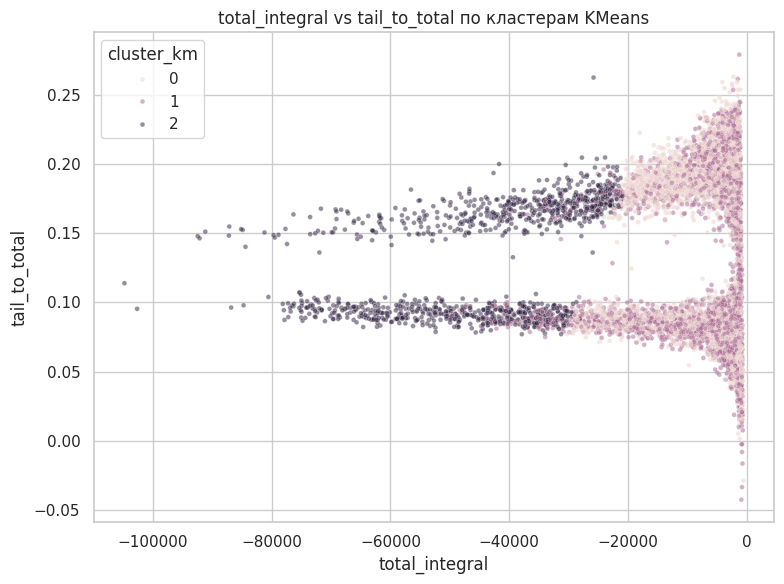

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=features_km.sample(8000, random_state=random_state),
    x="total_integral",
    y="tail_to_total",
    hue="cluster_km",
    alpha=0.5,
    s=12
)
plt.title("total_integral vs tail_to_total по кластерам KMeans")
plt.xlabel("total_integral")
plt.ylabel("tail_to_total")
plt.tight_layout()
plt.show()

Из Scatter видно, что при больших по модулю отрицательных total_integral (слева, мощные импульсы) видно две чёткие «полосы» по tail_to_total:
одна с более высокой долей хвоста (верхняя ветка), другая с меньшей долей хвоста (нижняя ветка).

В районе малых по модулю интегралов (справа, слабые события) кластеры сильно перемешаны и распределения размазываются — это кандидаты на «аномальный/смешанный» кластер.

На основании анализа параметров tail_to_total и total_integral по кластерам предположим следующее сопоставление кластеров KMeans с физическими классами. Кластер 0, характеризующийся наибольшей долей хвоста (tail_to_total) и средними по модулю интегралами, интерпретируется как нейтронные события (класс 1). Кластер 1 имеет минимальное значение tail_to_total и меньший total_integral, что соответствует сигналам, соответствующим второму типу частиц,(класс 0). Кластер 2 объединяет события с наибольшими по модулю интегралами и широким разбросом признаков это аномальный или смешанный класс (класс 2)
Зафиксируем сопоставление кластеров: классы 0, 1, 2:

cluster 0 - class 1
cluster 1 - сlass 0,
cluster 2 - class 2

In [24]:
cluster_to_class = {
    0: 1,
    1: 0,
    2: 2
}

train_classes = np.vectorize(cluster_to_class.get)(labels_km)
display("Unique train_classes:", np.unique(train_classes))

'Unique train_classes:'

array([0, 1, 2])

Посчитаем распределение по классам

In [42]:
unique, counts = np.unique(train_classes, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u}: {c} events")

Class 0: 9732 events
Class 1: 10552 events
Class 2: 3195 events


Модель выделяет две крупные группы сигналов, соответствующие основным типам частиц, и отдельную компактную группу аномальных или смешанных событий, что согласуется с постановкой задачи.

Class 0: 9732 events - нейтроны Class 1: 10552 events - гамма Class 2: 3195 events- аномалии

Собираем датасет, мапим кластеры под заданный формат

In [44]:
final_dataset = features.copy()

final_dataset["cluster_km"] = labels_km
final_dataset["class"] = train_classes

print("Shape final_dataset:", final_dataset.shape)
display(final_dataset.head())

unique_clusters = np.sort(np.unique(labels_km))
print("Кластеры были:", unique_clusters)

cluster_remap = {old: new for new, old in enumerate(unique_clusters)}
print("Отображение кластеров:", cluster_remap)

clusters_ordered = np.vectorize(cluster_remap.get)(labels_km)
print("Новые кластеры:", np.unique(clusters_ordered))

submission_df = pd.DataFrame({
    "index": np.arange(len(clusters_ordered)),
    "cluster": clusters_ordered
})
print(submission_df.head())
print("Shape submission_df:", submission_df.shape)

Shape final_dataset: (23479, 8)


,total_integral,tail_integral,tail_to_total,peak_amplitude,t_peak,rise_time_10_90,cluster_km,class
0,-4002.1,-741.2,0.185203,8.87,25,24,0,1
1,-11731.9,-988.8,0.084283,5.53,26,23,0,1
2,-16304.4,-1409.8,0.086467,8.08,338,335,1,0
3,-4151.2,-697.4,0.168000,8.24,320,320,1,0
4,-11298.1,-942.2,0.083395,6.57,36,36,0,1


Кластеры были: [0 1 2]
Отображение кластеров: {np.int32(0): 0, np.int32(1): 1, np.int32(2): 2}
Новые кластеры: [0 1 2]
   index  cluster
0      0        0
1      1        0
2      2        1
3      3        1
4      4        0
Shape submission_df: (23479, 2)


In [46]:
submission_path = "submission_with_clusters.csv"
submission_df.to_csv(submission_path, index=False)
print("Файл сохранён:", submission_path)

from google.colab import files
files.download(submission_path)

Файл сохранён: submission_with_clusters.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

В работе был проанализирован набор сцинтилляционных сигналов, где каждый сигнал представлен 500 временными отсчётами. После удаления служебных столбцов был получен чистый датасет без пропусков, дубликатов и константных признаков.

Предварительный анализ показал, что в раннем временном окне сигнал практически постоянен и соответствует baseline, тогда как основная вариативность сосредоточена в области импульса. На этой основе были построены физически интерпретируемые признаки: полный интеграл импульса total_integral, интеграл хвостовой части tail_integral, отношение tail_to_total, максимальная амплитуда peak_amplitud, положение пика t_peak и время нарастания rise_time_10_90.

Корреляционный анализ показал, что признаки total_integral и tail_integral сильно связаны между собой,а  tail_to_total слабо коррелирует с интегральными характеристиками. Это делает его  важным для разделения событий по форме импульса.

После стандартизации признаков был выполнен анализ главных компонент. Первые две компоненты объясняют около 69% общей дисперсии, что позволяет использовать двумерную PCA-проекцию для визуального анализа структуры данных.

Для кластеризации были рассмотрены модели KMeans и Gaussian Mixture Model при фиксированном числе кластеров k=3. В качестве основной модели был выбран алгоритм KMeans, показавший коэффициент силуэта около 0.34 и обеспечивший интерпретируемое разбиение пространства признаков.

Анализ кластеров показал, что:
один кластер соответствует событиям с повышенной долей хвоста и умеренными интегралами — такие сигналы интерпретируются как нейтроноподобные,второй кластер содержит события с меньшей долей хвоста и более «быстрыми» характеристиками — он интерпретируется как гамма-подобный, третий кластер объединяет сигналы с наибольшими по модулю интегралами и широким разбросом признаков, что позволяет рассматривать его как аномальный или смешанный класс.
После сопоставления кластеров с физическими классами получено следующее распределение объектов:
класс 0 — 9732 событий;
класс 1 — 10552 событий;
класс 2 — 3195 событий.

Таким образом, кластеризация KMeans позволили выделить две крупные группы сигналов, соответствующие основным типам частиц, а также отдельную группу аномальных событий. Полученные результаты согласуются со смыслом задачи и показывают, что  характеристики импульса являются наиболее информативными признаками для разделения сигналов.

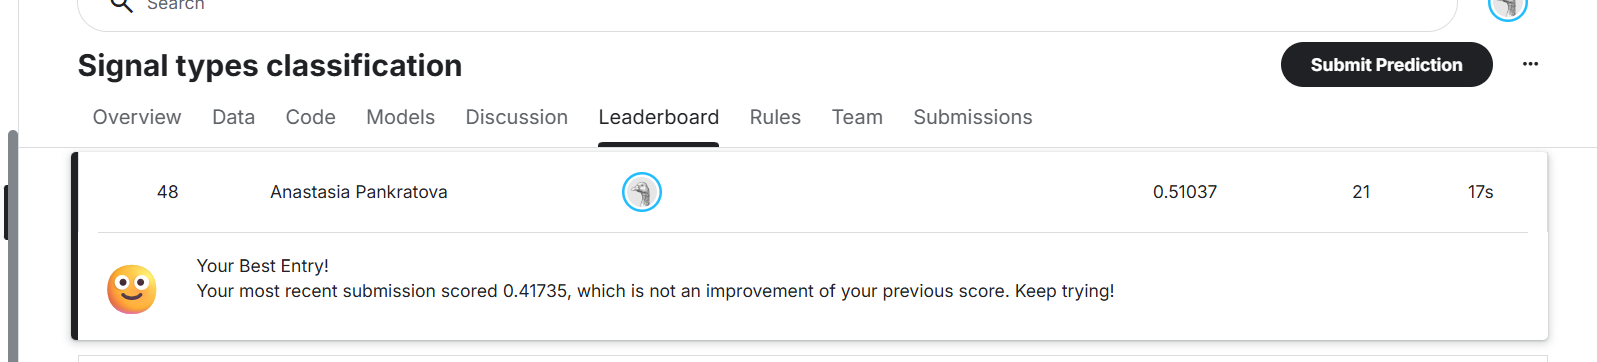